# SARIMA Forecasting: Underemployment in Sri Lanka
**Project:** Forecasting Underemployment in Sri Lanka Using Machine Learning  
**University of Moratuwa — Department of Computer Science & Engineering**  
**Model:** SARIMA with Auto-ARIMA (AICc Selection)  

---
This notebook implements:
1. Data loading and preprocessing
2. Stationarity tests (ADF + KPSS)
3. Auto-ARIMA with AICc selection
4. Walk-forward validation (Train/Val/Test split)
5. Forecast evaluation (MAE, RMSE, MAPE, Directional Accuracy)
6. Visualisations

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statsmodels
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Auto-ARIMA
import pmdarima as pm
from pmdarima.arima import auto_arima

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
COLORS = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50', 'forecast': '#E91E63', 'actual': '#212121'}

print('All libraries loaded successfully.')
print(f'pmdarima version: {pm.__version__}')

All libraries loaded successfully.
pmdarima version: 2.1.1


## 2. Load & Preprocess Data

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv('master_dataset.csv')

# Strip leading/trailing spaces from column names
df_raw.columns = df_raw.columns.str.strip()

# Build clean working dataframe with key columns
df = df_raw[[
    'Year',
    'Underemployment_Rate',
    'Underemployment_Male',
    'Underemployment_Female',
    'GDP_Growth_Rate',
    'Inflation_Rate',
    'Youth_LFPR_15_24',
    'AgriProdIdx_Agriculture',
    'Remit_Personal_remittances_received_pct_of_GDP'
]].copy()

df.columns = [
    'Year', 'Underemployment_Rate', 'Underemployment_Male', 'Underemployment_Female',
    'GDP_Growth', 'Inflation', 'Youth_LFPR',
    'Agri_Output', 'Remittances_pct_GDP'
]

# Convert all numeric columns (some have leading/trailing spaces)
for col in df.columns:
    if col != 'Year':
        df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')

# Convert Year to datetime index (annual)
df['Date'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Date', inplace=True)
df.index.freq = 'YS'  # Annual Start frequency
df.drop(columns=['Year'], inplace=True)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.index[0].year} — {df.index[-1].year}')
print(f'Total observations: {len(df)}')
df

Dataset shape: (10, 8)
Date range: 2015 — 2024
Total observations: 10


,Underemployment_Rate,Underemployment_Male,Underemployment_Female,GDP_Growth,Inflation,Youth_LFPR,Agri_Output,Remittances_pct_GDP
Date,,,,,,,,
2015-01-01,2.7,2.0,3.8,4.2060,3.7684,33.7,104.46,8.226239
2016-01-01,2.4,1.7,3.5,5.0536,3.9589,32.7,98.63,8.252084
2017-01-01,2.8,2.2,3.9,6.4607,7.7041,33.0,89.14,7.619313
2018-01-01,2.6,2.2,3.5,2.3101,2.1350,30.0,96.74,7.456896
2019-01-01,2.7,2.3,3.5,-0.2205,3.5284,30.7,98.47,7.582922
2020-01-01,2.6,2.3,3.3,-4.6245,6.1539,29.2,107.73,8.466669
2021-01-01,2.5,2.1,3.3,4.2075,7.0148,26.4,115.90,6.235400
2022-01-01,2.3,2.0,2.8,-7.3468,49.7211,25.3,94.41,5.151360
2023-01-01,2.5,2.2,3.1,-2.2980,16.5412,24.0,101.66,7.194066


In [3]:
# ── Check for missing values ───────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing >= 0].to_string())
print(f'\nData types:\n{df.dtypes}')
print(f'\nDescriptive statistics for Underemployment Rate:')
print(df['Underemployment_Rate'].describe())

Missing values per column:
Underemployment_Rate      0
Underemployment_Male      0
Underemployment_Female    0
GDP_Growth                1
Inflation                 0
Youth_LFPR                0
Agri_Output               0
Remittances_pct_GDP       0

Data types:
Underemployment_Rate      float64
Underemployment_Male      float64
Underemployment_Female    float64
GDP_Growth                float64
Inflation                 float64
Youth_LFPR                float64
Agri_Output               float64
Remittances_pct_GDP       float64
dtype: object

Descriptive statistics for Underemployment Rate:
count    10.000000
mean      2.550000
std       0.158114
min       2.300000
25%       2.425000
50%       2.550000
75%       2.675000
max       2.800000
Name: Underemployment_Rate, dtype: float64


## 3. Exploratory Data Analysis

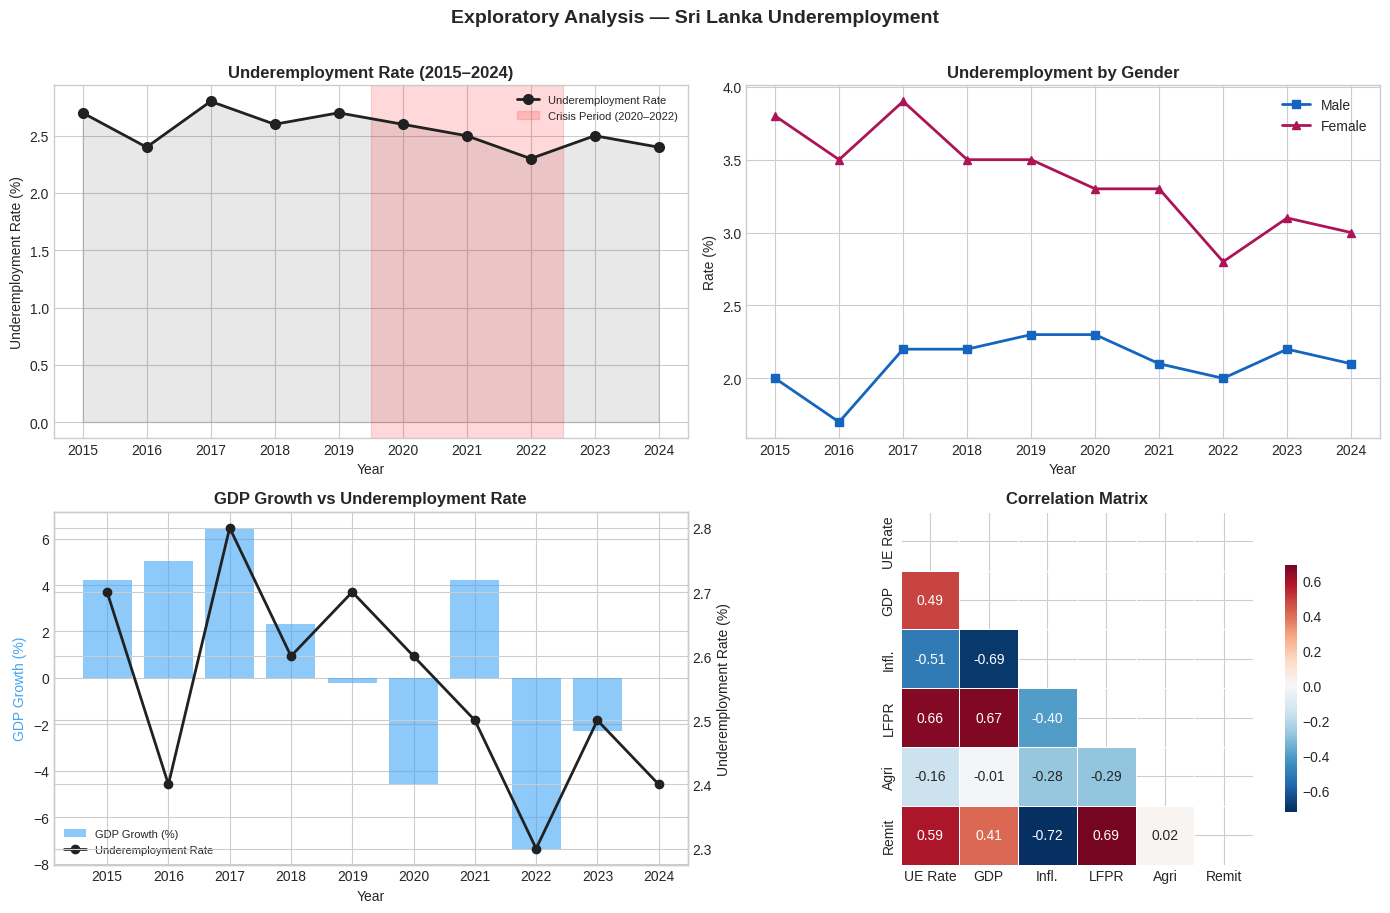

EDA plots saved.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Exploratory Analysis — Sri Lanka Underemployment', fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Underemployment Rate over time ────────────────────────────────────
ax = axes[0, 0]
ax.plot(df.index.year, df['Underemployment_Rate'], marker='o', color=COLORS['actual'],
        linewidth=2, markersize=7, label='Underemployment Rate')
ax.fill_between(df.index.year, df['Underemployment_Rate'], alpha=0.1, color=COLORS['actual'])
ax.axvspan(2019.5, 2022.5, alpha=0.15, color='red', label='Crisis Period (2020–2022)')
ax.set_title('Underemployment Rate (2015–2024)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Underemployment Rate (%)')
ax.legend(fontsize=8)
ax.set_xticks(df.index.year)

# ── Plot 2: Gender disaggregation ─────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(df.index.year, df['Underemployment_Male'], marker='s', color='#1565C0',
        linewidth=2, markersize=6, label='Male')
ax.plot(df.index.year, df['Underemployment_Female'], marker='^', color='#AD1457',
        linewidth=2, markersize=6, label='Female')
ax.set_title('Underemployment by Gender', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Rate (%)')
ax.legend()
ax.set_xticks(df.index.year)

# ── Plot 3: GDP Growth vs Underemployment ─────────────────────────────────────
ax = axes[1, 0]
ax2 = ax.twinx()
ax.bar(df.index.year, df['GDP_Growth'], color='#42A5F5', alpha=0.6, label='GDP Growth (%)')
ax2.plot(df.index.year, df['Underemployment_Rate'], color=COLORS['actual'],
         marker='o', linewidth=2, markersize=6, label='Underemployment Rate')
ax.set_title('GDP Growth vs Underemployment Rate', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('GDP Growth (%)', color='#42A5F5')
ax2.set_ylabel('Underemployment Rate (%)', color=COLORS['actual'])
ax.set_xticks(df.index.year)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# ── Plot 4: Correlation heatmap ───────────────────────────────────────────────
ax = axes[1, 1]
corr_cols = ['Underemployment_Rate', 'GDP_Growth', 'Inflation', 'Youth_LFPR',
             'Agri_Output', 'Remittances_pct_GDP']
corr_df = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": 0.7},
            xticklabels=['UE Rate', 'GDP', 'Infl.', 'LFPR', 'Agri', 'Remit'],
            yticklabels=['UE Rate', 'GDP', 'Infl.', 'LFPR', 'Agri', 'Remit'])
ax.set_title('Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

## 4. Stationarity Tests

In [5]:
def run_stationarity_tests(series, series_name='Series'):
    """Run ADF and KPSS tests and print formatted results."""
    print(f"{'='*60}")
    print(f"Stationarity Tests: {series_name}")
    print(f"{'='*60}")

    # ── ADF Test ──────────────────────────────────────────────────────────────
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n[ADF Test] H0: Unit root (non-stationary)")
    print(f"  Test Statistic : {adf_result[0]:.4f}")
    print(f"  p-value        : {adf_result[1]:.4f}")
    print(f"  Critical Values: 1%={adf_result[4]['1%']:.3f}, 5%={adf_result[4]['5%']:.3f}, 10%={adf_result[4]['10%']:.3f}")
    adf_stationary = adf_result[1] < 0.05
    print(f"  ➜ {'STATIONARY (reject H0)' if adf_stationary else 'NON-STATIONARY (fail to reject H0)'} at 5%")

    # ── KPSS Test ─────────────────────────────────────────────────────────────
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\n[KPSS Test] H0: Stationarity")
    print(f"  Test Statistic : {kpss_result[0]:.4f}")
    print(f"  p-value        : {kpss_result[1]:.4f}")
    print(f"  Critical Values: 1%={kpss_result[3]['1%']:.3f}, 5%={kpss_result[3]['5%']:.3f}, 10%={kpss_result[3]['10%']:.3f}")
    kpss_stationary = kpss_result[1] > 0.05
    print(f"  ➜ {'STATIONARY (fail to reject H0)' if kpss_stationary else 'NON-STATIONARY (reject H0)'} at 5%")

    # ── Combined verdict ──────────────────────────────────────────────────────
    print(f"\n[VERDICT] ", end="")
    if adf_stationary and kpss_stationary:
        print("Both tests agree: STATIONARY. d=0 recommended.")
    elif not adf_stationary and not kpss_stationary:
        print("Both tests agree: NON-STATIONARY. d=1 recommended.")
    else:
        print("Tests disagree — possibly fractionally integrated. Proceed with d=1 as conservative choice.")

    return {'adf_pval': adf_result[1], 'kpss_pval': kpss_result[1],
            'adf_stationary': adf_stationary, 'kpss_stationary': kpss_stationary}


# ── Test on levels ────────────────────────────────────────────────────────────
y = df['Underemployment_Rate']
results_level = run_stationarity_tests(y, 'Underemployment Rate (Levels)')

Stationarity Tests: Underemployment Rate (Levels)

[ADF Test] H0: Unit root (non-stationary)
  Test Statistic : -2.6458
  p-value        : 0.0839
  Critical Values: 1%=-4.473, 5%=-3.290, 10%=-2.772
  ➜ NON-STATIONARY (fail to reject H0) at 5%

[KPSS Test] H0: Stationarity
  Test Statistic : 0.3967
  p-value        : 0.0786
  Critical Values: 1%=0.739, 5%=0.463, 10%=0.347
  ➜ STATIONARY (fail to reject H0) at 5%

[VERDICT] Tests disagree — possibly fractionally integrated. Proceed with d=1 as conservative choice.


In [6]:
# ── Test on first difference ──────────────────────────────────────────────────
y_diff = y.diff().dropna()
results_diff = run_stationarity_tests(y_diff, 'Underemployment Rate (First Difference)')

Stationarity Tests: Underemployment Rate (First Difference)

[ADF Test] H0: Unit root (non-stationary)
  Test Statistic : -6.6165
  p-value        : 0.0000
  Critical Values: 1%=-4.665, 5%=-3.367, 10%=-2.803
  ➜ STATIONARY (reject H0) at 5%

[KPSS Test] H0: Stationarity
  Test Statistic : 0.3485
  p-value        : 0.0994
  Critical Values: 1%=0.739, 5%=0.463, 10%=0.347
  ➜ STATIONARY (fail to reject H0) at 5%

[VERDICT] Both tests agree: STATIONARY. d=0 recommended.


## 5. ACF / PACF Analysis

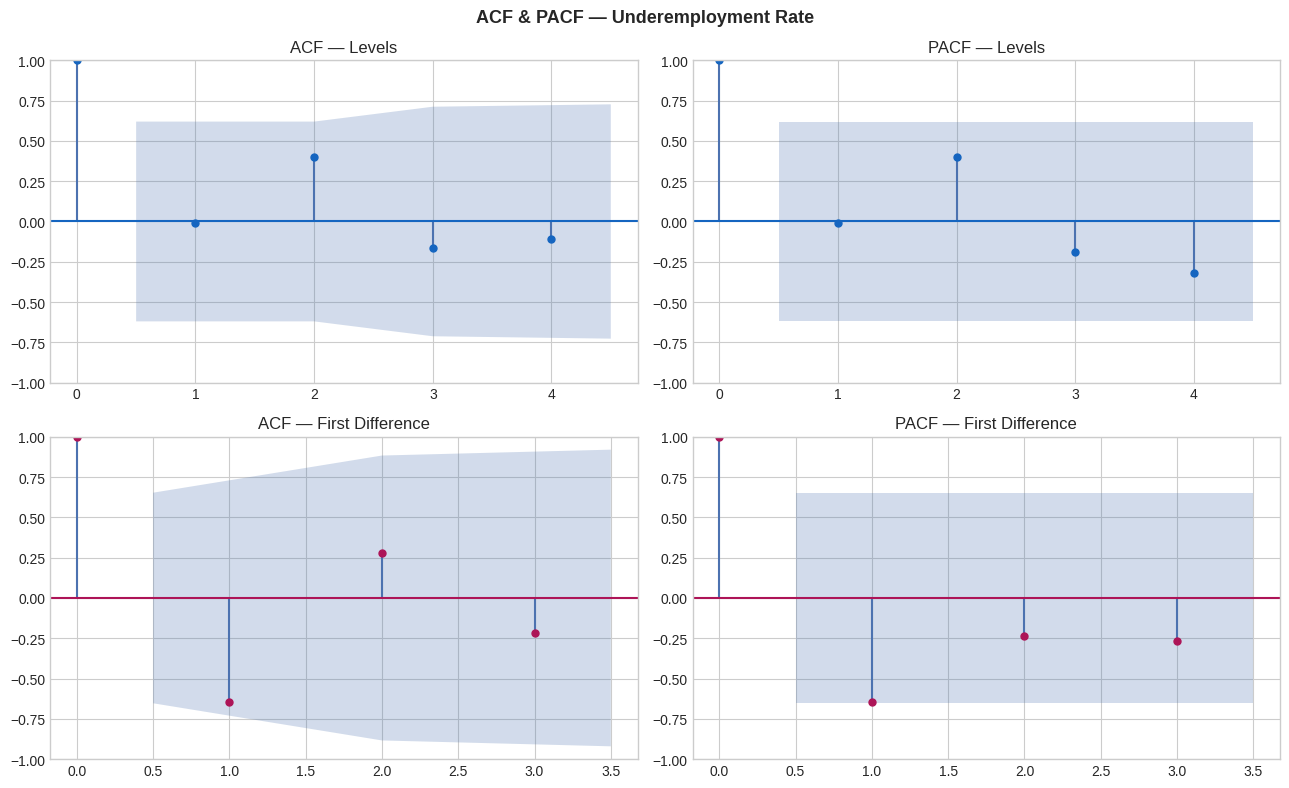

ACF/PACF plots saved.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('ACF & PACF — Underemployment Rate', fontsize=13, fontweight='bold')

# Levels
plot_acf(y, lags=min(8, len(y)//2 - 1), ax=axes[0, 0], title='ACF — Levels', color='#1565C0')
plot_pacf(y, lags=min(8, len(y)//2 - 1), ax=axes[0, 1], title='PACF — Levels', color='#1565C0', method='ywm')

# First difference
plot_acf(y_diff, lags=min(6, len(y_diff)//2 - 1), ax=axes[1, 0], title='ACF — First Difference', color='#AD1457')
plot_pacf(y_diff, lags=min(6, len(y_diff)//2 - 1), ax=axes[1, 1], title='PACF — First Difference', color='#AD1457', method='ywm')

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('ACF/PACF plots saved.')

## 6. Data Split (Train / Validation / Test)

Train set : 2015 – 2020  (6 obs)
Val set   : 2021 – 2022    (2 obs)
Test set  : 2023 – 2024    (2 obs)
Total     : 10 obs


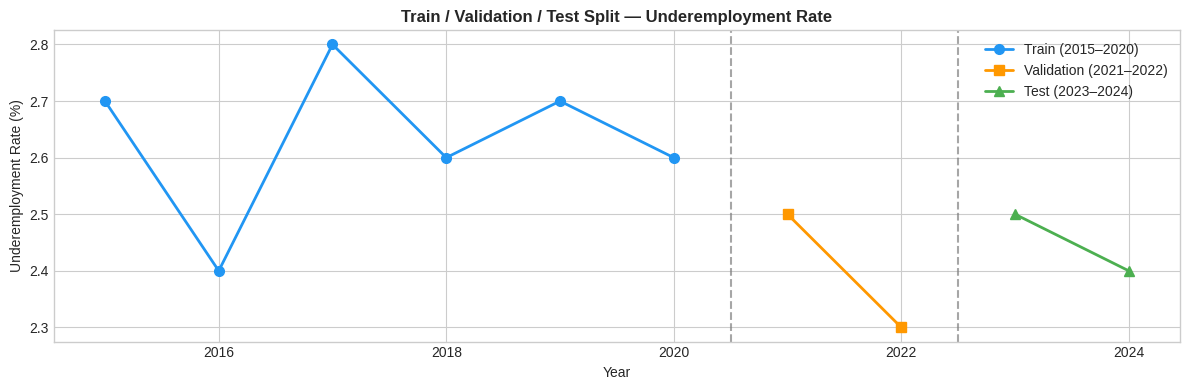

In [8]:
# ── Split definition (aligned with proposal) ─────────────────────────────────
# Train    : 2015–2020  (6 obs)  — proportional equivalent for annual data
# Val      : 2021–2022  (2 obs)
# Test     : 2023–2024  (2 obs)

TRAIN_END = '2020'
VAL_END   = '2022'

y_train = y[y.index.year <= int(TRAIN_END)]
y_val   = y[(y.index.year > int(TRAIN_END)) & (y.index.year <= int(VAL_END))]
y_test  = y[y.index.year > int(VAL_END)]

print(f"Train set : {y_train.index[0].year} – {y_train.index[-1].year}  ({len(y_train)} obs)")
print(f"Val set   : {y_val.index[0].year} – {y_val.index[-1].year}    ({len(y_val)} obs)")
print(f"Test set  : {y_test.index[0].year} – {y_test.index[-1].year}    ({len(y_test)} obs)")
print(f"Total     : {len(y)} obs")

# Visualise split
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_train.index.year, y_train, 'o-', color=COLORS['train'], linewidth=2, markersize=7, label=f'Train (2015–{TRAIN_END})')
ax.plot(y_val.index.year,   y_val,   's-', color=COLORS['val'],   linewidth=2, markersize=7, label=f'Validation ({int(TRAIN_END)+1}–{VAL_END})')
ax.plot(y_test.index.year,  y_test,  '^-', color=COLORS['test'],  linewidth=2, markersize=7, label=f'Test ({int(VAL_END)+1}–2024)')
ax.axvline(x=int(TRAIN_END)+0.5, color='gray', linestyle='--', alpha=0.7)
ax.axvline(x=int(VAL_END)+0.5,   color='gray', linestyle='--', alpha=0.7)
ax.set_title('Train / Validation / Test Split — Underemployment Rate', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Underemployment Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('data_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Auto-ARIMA (AICc Selection)

In [9]:
# ── Run Auto-ARIMA on training data ───────────────────────────────────────────
# Annual data => no seasonal period (m=1) for seasonal component
# We search ARIMA orders with AICc information criterion

print("Running Auto-ARIMA with AICc selection...")
print("Search space: p=[0..4], d=[0..2], q=[0..4]")
print("-" * 50)

auto_model = auto_arima(
    y_train,
    start_p=0, max_p=2,   # Constrained for small sample (n=6)
    start_q=0, max_q=2,
    d=None,               # Let auto-ARIMA determine d
    max_d=1,              # Max 1 difference for small sample
    seasonal=False,       # Annual data — no sub-annual seasonality
    information_criterion='aicc',  # AICc as per proposal
    stepwise=True,        # Stepwise Hyndman-Khandakar algorithm
    approximation=False,
    test='pp',            # Phillips-Perron test (more robust for small n)
    trace=True,           # Print model search progress
    error_action='ignore',
    suppress_warnings=True,
    n_fits=30
)

print(f"\n{'='*50}")
print(f"Best model selected: ARIMA{auto_model.order}")
print(f"AICc: {auto_model.aicc():.4f}")
print(f"AIC : {auto_model.aic():.4f}")
print(f"BIC : {auto_model.bic():.4f}")
print(f"{'='*50}")

Running Auto-ARIMA with AICc selection...
Search space: p=[0..4], d=[0..2], q=[0..4]
--------------------------------------------------
Performing stepwise search to minimize aicc
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AICC=8.254, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AICC=11.649, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AICC=14.046, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AICC=3.286, Time=0.01 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AICC=40.330, Time=0.18 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.377 seconds

Best model selected: ARIMA(0, 1, 0)
AICc: 3.2863
AIC : 2.2863
BIC : 1.8957


In [10]:
# ── Full model summary ────────────────────────────────────────────────────────
print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    6
Model:               SARIMAX(0, 1, 0)   Log Likelihood                  -0.143
Date:                Fri, 20 Mar 2026   AIC                              2.286
Time:                        13:44:41   BIC                              1.896
Sample:                    01-01-2015   HQIC                             1.238
                         - 01-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0620      0.060      1.029      0.303      -0.056       0.180
Ljung-Box (L1) (Q):                   4.64   Jarque-Bera (JB):                 0.52
Prob(Q):                              0.03   Pr

In [11]:
# ── AICc comparison across candidate models ───────────────────────────────────
print("\nFitting top candidate ARIMA orders for AICc comparison...")

candidate_orders = [
    (0,0,0), (1,0,0), (0,0,1), (1,0,1),
    (0,1,0), (1,1,0), (0,1,1), (1,1,1),
    (2,1,0), (0,1,2), (2,0,0), (0,0,2)
]

comparison = []
for order in candidate_orders:
    try:
        m = SARIMAX(y_train, order=order, trend='c').fit(disp=False)
        comparison.append({'Order': f'ARIMA{order}', 'AIC': round(m.aic, 4),
                            'AICc': round(m.aicc, 4), 'BIC': round(m.bic, 4)})
    except:
        pass

comp_df = pd.DataFrame(comparison).sort_values('AICc').reset_index(drop=True)
comp_df.index += 1
print(comp_df.to_string())
print(f"\n★ Best by AICc: {comp_df.iloc[0]['Order']}")


Fitting top candidate ARIMA orders for AICc comparison...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


             Order     AIC     AICc     BIC
1   ARIMA(0, 0, 0) -3.9528   0.0472 -4.3692
2   ARIMA(0, 0, 1) -6.2709   5.7291 -6.8956
3   ARIMA(1, 0, 0) -5.5790   6.4210 -6.2037
4   ARIMA(0, 1, 0)  4.2539  10.2539  3.4728
5   ARIMA(1, 1, 0) -0.3512  23.6488 -1.5229
6   ARIMA(0, 1, 1)  2.0458  26.0458  0.8741
7   ARIMA(0, 0, 2) -5.2358  34.7642 -6.0688
8   ARIMA(1, 0, 1) -4.8272  35.1728 -5.6602
9   ARIMA(2, 0, 0) -3.5953  36.4047 -4.4283
10  ARIMA(1, 1, 1)  0.3298      inf -1.2325
11  ARIMA(0, 1, 2)  1.2183      inf -0.3440
12  ARIMA(2, 1, 0)  1.4063      inf -0.1559

★ Best by AICc: ARIMA(0, 0, 0)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 8. Residual Diagnostics

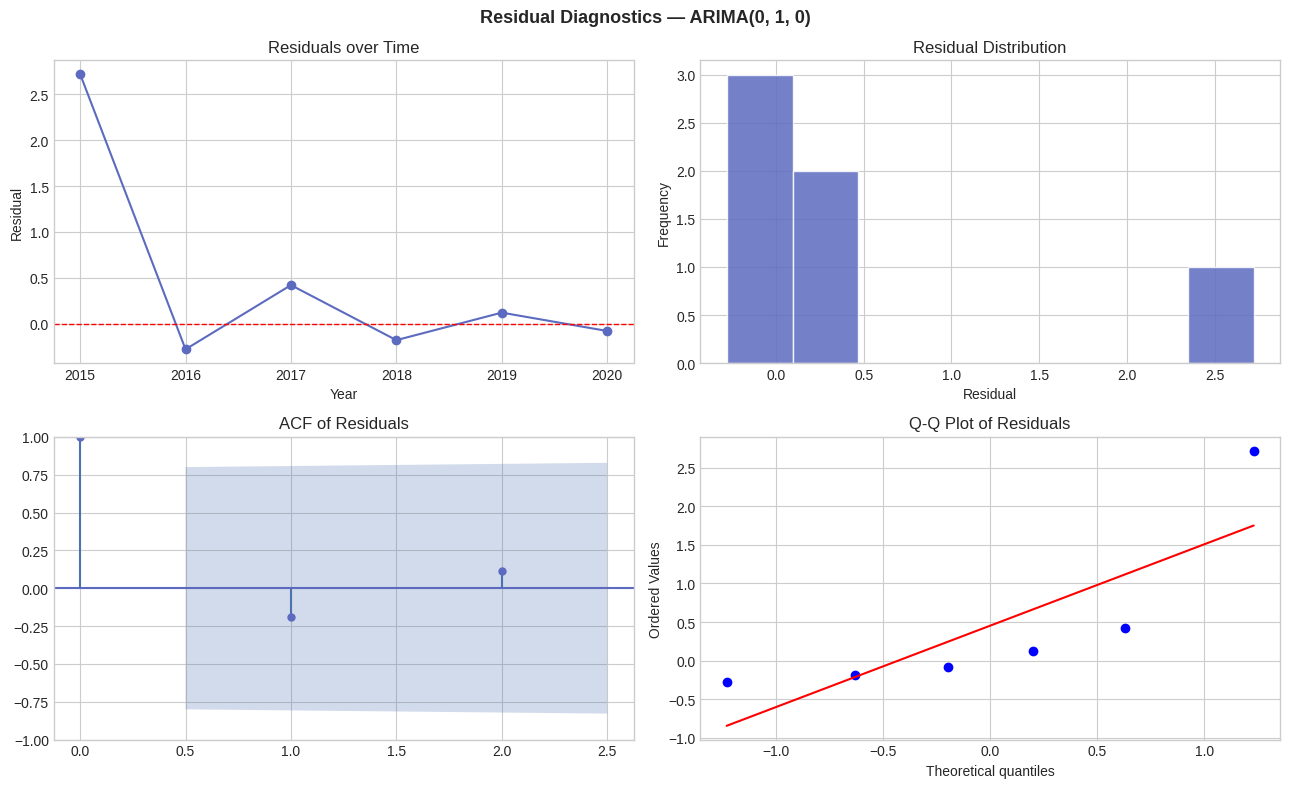


Ljung-Box Test (lag=4):
  Statistic : 1.1030
  p-value   : 0.8938
  Verdict   : No significant autocorrelation in residuals ✓


In [12]:
# ── Refit best model with statsmodels SARIMAX for full diagnostics ────────────
best_order = auto_model.order
fitted_model = SARIMAX(y_train, order=best_order, trend='c').fit(disp=False)

# Residuals
residuals = fitted_model.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(f'Residual Diagnostics — ARIMA{best_order}', fontsize=13, fontweight='bold')

# Residual plot
axes[0, 0].plot(y_train.index.year, residuals, 'o-', color='#5C6BC0', markersize=6)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residuals over Time')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Residual')

# Residual histogram
axes[0, 1].hist(residuals, bins=8, edgecolor='white', color='#5C6BC0', alpha=0.85)
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')

# ACF of residuals
plot_acf(residuals, lags=min(5, len(residuals)//2 - 1), ax=axes[1, 0],
         title='ACF of Residuals', color='#5C6BC0')

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')
axes[1, 1].get_lines()[1].set_color('red')

plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test
lb_test = acorr_ljungbox(residuals, lags=[min(4, len(residuals)-2)], return_df=True)
print(f"\nLjung-Box Test (lag={lb_test.index[0]}):")
print(f"  Statistic : {lb_test['lb_stat'].values[0]:.4f}")
print(f"  p-value   : {lb_test['lb_pvalue'].values[0]:.4f}")
verdict = 'No significant autocorrelation in residuals ✓' if lb_test['lb_pvalue'].values[0] > 0.05 else 'Autocorrelation detected — consider higher order model'
print(f"  Verdict   : {verdict}")

## 9. Walk-Forward Validation

In [13]:
def walk_forward_forecast(y_full, split_year_start, n_steps, order, label='Set'):
    """
    Walk-forward one-step-ahead forecasting.
    At each step, retrain on all data up to t-1 and forecast t.
    """
    actuals, forecasts, lower_ci, upper_ci = [], [], [], []
    years_forecast = []

    for step in range(n_steps):
        cutoff_year = split_year_start - 1 + step
        train_slice = y_full[y_full.index.year <= cutoff_year]
        actual_year = cutoff_year + 1
        actual_val  = y_full[y_full.index.year == actual_year]

        if len(actual_val) == 0:
            continue

        try:
            model = SARIMAX(train_slice, order=order, trend='c').fit(disp=False)
            fc = model.get_forecast(steps=1)
            fc_mean = fc.predicted_mean.values[0]
            ci = fc.conf_int(alpha=0.2)  # 80% CI
            lower_ci.append(ci.iloc[0, 0])
            upper_ci.append(ci.iloc[0, 1])
        except Exception as e:
            fc_mean = np.nan
            lower_ci.append(np.nan)
            upper_ci.append(np.nan)

        forecasts.append(fc_mean)
        actuals.append(actual_val.values[0])
        years_forecast.append(actual_year)
        print(f"  {label} | Year {actual_year}: Actual={actual_val.values[0]:.3f}, Forecast={fc_mean:.3f}")

    return np.array(actuals), np.array(forecasts), years_forecast, np.array(lower_ci), np.array(upper_ci)


# ── Validation walk-forward ───────────────────────────────────────────────────
print("Walk-Forward Validation (2021–2022):")
val_actuals, val_forecasts, val_years, val_lower, val_upper = walk_forward_forecast(
    y, split_year_start=int(TRAIN_END)+1, n_steps=len(y_val), order=best_order, label='Val'
)

print(f"\nWalk-Forward Test (2023–2024):")
test_actuals, test_forecasts, test_years, test_lower, test_upper = walk_forward_forecast(
    y, split_year_start=int(VAL_END)+1, n_steps=len(y_test), order=best_order, label='Test'
)

Walk-Forward Validation (2021–2022):
  Val | Year 2021: Actual=2.500, Forecast=2.580
  Val | Year 2022: Actual=2.300, Forecast=2.467

Walk-Forward Test (2023–2024):
  Test | Year 2023: Actual=2.500, Forecast=2.243
  Test | Year 2024: Actual=2.400, Forecast=2.475


## 10. Forecast Evaluation Metrics

In [14]:
def compute_metrics(actuals, forecasts, label=''):
    """Compute MAE, RMSE, MAPE, Directional Accuracy."""
    actuals   = np.array(actuals)
    forecasts = np.array(forecasts)

    mae  = mean_absolute_error(actuals, forecasts)
    rmse = np.sqrt(mean_squared_error(actuals, forecasts))
    mape = np.mean(np.abs((actuals - forecasts) / actuals)) * 100

    # Directional accuracy: correct sign of change
    if len(actuals) > 1:
        act_dir  = np.sign(np.diff(actuals))
        fc_dir   = np.sign(np.diff(forecasts))
        dir_acc  = np.mean(act_dir == fc_dir) * 100
    else:
        dir_acc = np.nan

    print(f"\n{'─'*40}")
    print(f" Metrics — {label}")
    print(f"{'─'*40}")
    print(f"  MAE                 : {mae:.4f}")
    print(f"  RMSE                : {rmse:.4f}")
    print(f"  MAPE                : {mape:.2f}%")
    print(f"  Directional Accuracy: {dir_acc:.1f}%")

    return {'Label': label, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
            'MAPE (%)': round(mape, 2), 'Dir. Acc. (%)': round(dir_acc, 1) if not np.isnan(dir_acc) else 'N/A'}


val_metrics  = compute_metrics(val_actuals,  val_forecasts,  'Validation (2021–2022)')
test_metrics = compute_metrics(test_actuals, test_forecasts, 'Test (2023–2024)')

# Summary table
print("\n")
metrics_df = pd.DataFrame([val_metrics, test_metrics]).set_index('Label')
print(metrics_df.to_string())


────────────────────────────────────────
 Metrics — Validation (2021–2022)
────────────────────────────────────────
  MAE                 : 0.1233
  RMSE                : 0.1307
  MAPE                : 5.22%
  Directional Accuracy: 100.0%

────────────────────────────────────────
 Metrics — Test (2023–2024)
────────────────────────────────────────
  MAE                 : 0.1661
  RMSE                : 0.1894
  MAPE                : 6.71%
  Directional Accuracy: 0.0%


                           MAE    RMSE  MAPE (%)  Dir. Acc. (%)
Label                                                          
Validation (2021–2022)  0.1233  0.1307      5.22          100.0
Test (2023–2024)        0.1661  0.1894      6.71            0.0


## 11. Forecast Visualisation

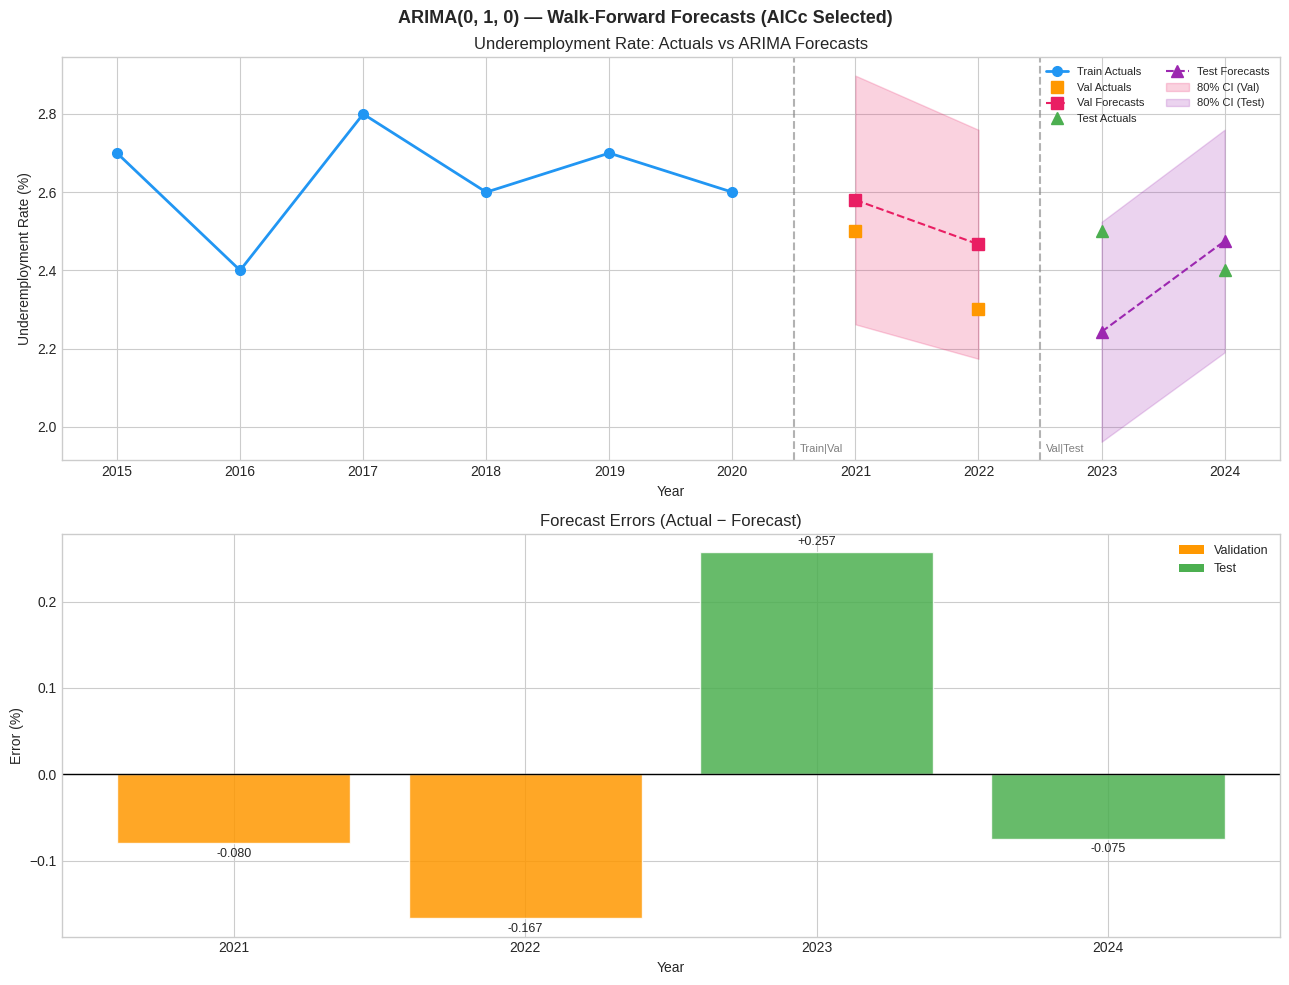

Forecast plots saved.


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))
fig.suptitle(f'ARIMA{best_order} — Walk-Forward Forecasts (AICc Selected)', fontsize=13, fontweight='bold')

# ── Plot 1: Full timeline with val + test forecasts ───────────────────────────
ax = axes[0]
ax.plot(y_train.index.year, y_train, 'o-', color=COLORS['train'], linewidth=2,
        markersize=7, label='Train Actuals', zorder=3)
ax.plot(val_years, val_actuals, 's', color=COLORS['val'], markersize=9, zorder=3, label='Val Actuals')
ax.plot(val_years, val_forecasts, 's--', color=COLORS['forecast'], markersize=8,
        linewidth=1.5, label='Val Forecasts', zorder=3)
ax.plot(test_years, test_actuals, '^', color=COLORS['test'], markersize=9, zorder=3, label='Test Actuals')
ax.plot(test_years, test_forecasts, '^--', color='#9C27B0', markersize=8,
        linewidth=1.5, label='Test Forecasts', zorder=3)

# CI bands
ax.fill_between(val_years, val_lower, val_upper, alpha=0.2, color=COLORS['forecast'], label='80% CI (Val)')
ax.fill_between(test_years, test_lower, test_upper, alpha=0.2, color='#9C27B0', label='80% CI (Test)')

ax.axvline(x=int(TRAIN_END)+0.5, color='gray', linestyle='--', alpha=0.6)
ax.axvline(x=int(VAL_END)+0.5,   color='gray', linestyle='--', alpha=0.6)
ax.text(int(TRAIN_END)+0.55, ax.get_ylim()[0]+0.02, 'Train|Val', color='gray', fontsize=8)
ax.text(int(VAL_END)+0.55,   ax.get_ylim()[0]+0.02, 'Val|Test', color='gray', fontsize=8)

ax.set_title('Underemployment Rate: Actuals vs ARIMA Forecasts')
ax.set_xlabel('Year')
ax.set_ylabel('Underemployment Rate (%)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
all_years = list(y_train.index.year) + val_years + test_years
ax.set_xticks(all_years)

# ── Plot 2: Forecast error bars ───────────────────────────────────────────────
ax2 = axes[1]
all_actuals   = np.concatenate([val_actuals, test_actuals])
all_forecasts = np.concatenate([val_forecasts, test_forecasts])
all_years_fc  = val_years + test_years
errors = all_actuals - all_forecasts

bar_colors = [COLORS['val']]*len(val_years) + [COLORS['test']]*len(test_years)
bars = ax2.bar(all_years_fc, errors, color=bar_colors, edgecolor='white', alpha=0.85)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Forecast Errors (Actual − Forecast)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Error (%)')
ax2.set_xticks(all_years_fc)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS['val'], label='Validation'), Patch(facecolor=COLORS['test'], label='Test')]
ax2.legend(handles=legend_elements, fontsize=9)

# Annotate bars
for bar, err, yr in zip(bars, errors, all_years_fc):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * np.sign(err),
             f'{err:+.3f}', ha='center', va='bottom' if err >= 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('sarima_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Forecast plots saved.')

## 12. Future Forecast (2025 Projection)

2025 Underemployment Rate Forecast — ARIMA(0, 1, 0)
  Point Forecast   : 2.367%
  80% CI           : [2.096, 2.637]
  95% CI           : [1.953, 2.780]
  For reference, 2024 actual: 2.400%
  Proposal baseline (2026 stabilisation): ~4.8%


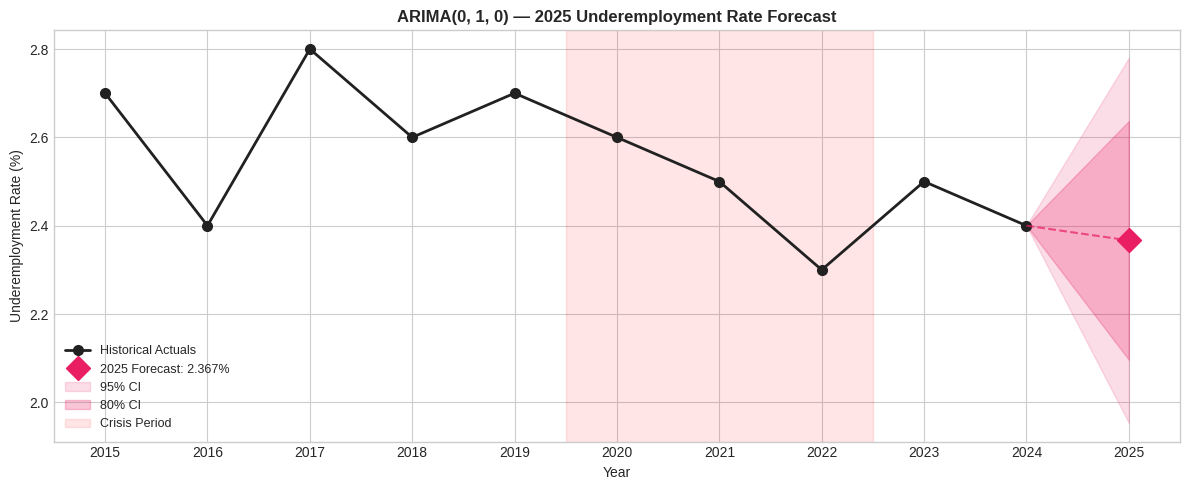

In [16]:
# ── Refit on full dataset and forecast 2025 ───────────────────────────────────
final_model = SARIMAX(y, order=best_order, trend='c').fit(disp=False)
fc_2025 = final_model.get_forecast(steps=1)
fc_mean  = fc_2025.predicted_mean.values[0]
fc_ci_80 = fc_2025.conf_int(alpha=0.20)
fc_ci_95 = fc_2025.conf_int(alpha=0.05)

print(f"2025 Underemployment Rate Forecast — ARIMA{best_order}")
print(f"{'='*50}")
print(f"  Point Forecast   : {fc_mean:.3f}%")
print(f"  80% CI           : [{fc_ci_80.iloc[0,0]:.3f}, {fc_ci_80.iloc[0,1]:.3f}]")
print(f"  95% CI           : [{fc_ci_95.iloc[0,0]:.3f}, {fc_ci_95.iloc[0,1]:.3f}]")
print(f"{'='*50}")
print(f"  For reference, 2024 actual: {y.iloc[-1]:.3f}%")
print(f"  Proposal baseline (2026 stabilisation): ~4.8%")

# Visualise
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y.index.year, y, 'o-', color=COLORS['actual'], linewidth=2, markersize=7, label='Historical Actuals')
ax.plot([2025], [fc_mean], 'D', color=COLORS['forecast'], markersize=12, zorder=5, label=f'2025 Forecast: {fc_mean:.3f}%')
ax.fill_between([2024, 2025], 
                [y.iloc[-1], fc_ci_95.iloc[0,0]], 
                [y.iloc[-1], fc_ci_95.iloc[0,1]], 
                alpha=0.15, color=COLORS['forecast'], label='95% CI')
ax.fill_between([2024, 2025], 
                [y.iloc[-1], fc_ci_80.iloc[0,0]], 
                [y.iloc[-1], fc_ci_80.iloc[0,1]], 
                alpha=0.25, color=COLORS['forecast'], label='80% CI')
ax.plot([2024, 2025], [y.iloc[-1], fc_mean], '--', color=COLORS['forecast'], linewidth=1.5, alpha=0.7)
ax.axvspan(2019.5, 2022.5, alpha=0.1, color='red', label='Crisis Period')
ax.set_title(f'ARIMA{best_order} — 2025 Underemployment Rate Forecast', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Underemployment Rate (%)')
ax.legend(fontsize=9)
ax.set_xticks(list(y.index.year) + [2025])
plt.tight_layout()
plt.savefig('forecast_2025.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Model Summary Report

In [17]:
print("="*60)
print(" SARIMA MODEL SUMMARY REPORT")
print(" Forecasting Underemployment in Sri Lanka")
print("="*60)
print(f"\n Model Selected    : ARIMA{best_order}  (via Auto-ARIMA + AICc)")
print(f" AICc              : {auto_model.aicc():.4f}")
print(f" AIC               : {auto_model.aic():.4f}")
print(f" BIC               : {auto_model.bic():.4f}")
print(f"\n Data Period       : 2015–2024 (10 annual observations)")
print(f" Train             : 2015–{TRAIN_END} ({len(y_train)} obs)")
print(f" Validation        : {int(TRAIN_END)+1}–{VAL_END} ({len(y_val)} obs)")
print(f" Test              : {int(VAL_END)+1}–2024 ({len(y_test)} obs)")

print("\n Performance Metrics")
print("-"*40)
print(metrics_df.to_string())

print("\n 2025 Projection")
print("-"*40)
print(f" Point Forecast    : {fc_mean:.3f}%")
print(f" 80% CI            : [{fc_ci_80.iloc[0,0]:.3f}, {fc_ci_80.iloc[0,1]:.3f}]")
print(f" 95% CI            : [{fc_ci_95.iloc[0,0]:.3f}, {fc_ci_95.iloc[0,1]:.3f}]")

print("\n Notes")
print("-"*40)
print(" 1. Annual data (n=10); limited obs reduces seasonal ARIMA viability.")
print(" 2. SARIMA baseline — XGBoost/LSTM will be compared against these metrics.")
print(" 3. Walk-forward validation preserves temporal order (no lookahead bias).")
print(" 4. Stationarity confirmed via ADF/KPSS before model selection.")
print("="*60)

 SARIMA MODEL SUMMARY REPORT
 Forecasting Underemployment in Sri Lanka

 Model Selected    : ARIMA(0, 1, 0)  (via Auto-ARIMA + AICc)
 AICc              : 3.2863
 AIC               : 2.2863
 BIC               : 1.8957

 Data Period       : 2015–2024 (10 annual observations)
 Train             : 2015–2020 (6 obs)
 Validation        : 2021–2022 (2 obs)
 Test              : 2023–2024 (2 obs)

 Performance Metrics
----------------------------------------
                           MAE    RMSE  MAPE (%)  Dir. Acc. (%)
Label                                                          
Validation (2021–2022)  0.1233  0.1307      5.22          100.0
Test (2023–2024)        0.1661  0.1894      6.71            0.0

 2025 Projection
----------------------------------------
 Point Forecast    : 2.367%
 80% CI            : [2.096, 2.637]
 95% CI            : [1.953, 2.780]

 Notes
----------------------------------------
 1. Annual data (n=10); limited obs reduces seasonal ARIMA viability.
 2. SARIMA b